In [1]:
import os
import sys
os.environ['PYTHONWARNINGS'] = 'ignore'
class NullWriter:
    def write(self, msg):
        pass
    def flush(self):
        pass
sys.stderr = NullWriter()

In [2]:
import celldyc as cdc
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import moscot as mt
import cellrank as cr
import wot

In [3]:
adata=cdc.datasets.simudata()
#adata = sc.read_h5ad("scdesign3_5000c500g.h5ad")
adata

Saved to: data\scdesign3_5000c500g.h5ad


AnnData object with n_obs × n_vars = 5000 × 500
    obs: 'pseudotime'
    var: 'gene'
    obsm: 'X_umap'
    layers: 'velocity_true'

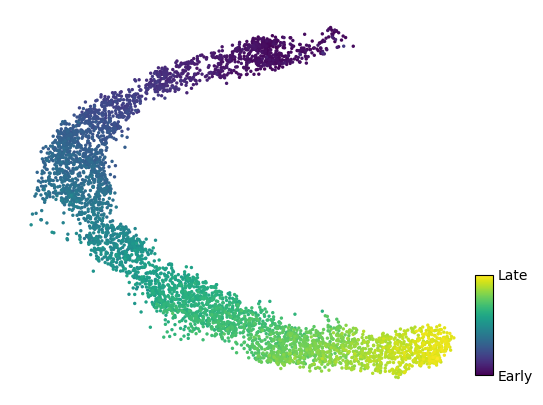

In [4]:
sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
fig, ax = plt.subplots(figsize=(6, 5))
ax = sc.pl.embedding(
    adata,
    color="pseudotime",
    basis="umap",
    show=False,
    ax=ax,
    title=" ",
    colorbar_loc=None,
)
ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("")
for spine in ax.spines.values():
    spine.set_visible(False)
fig = plt.gcf()
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.2])
pseudotime_data = adata.obs["pseudotime"]
vmin, vmax = pseudotime_data.min(), pseudotime_data.max()

cmap = plt.get_cmap("viridis")
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cb = mpl.colorbar.ColorbarBase(cbar_ax, cmap=cmap, norm=norm, orientation="vertical")
cb.set_ticks([vmin, vmax])
cb.set_ticklabels(["Early", "Late"])
cb.ax.tick_params(size=0, labelsize=10)
plt.show()

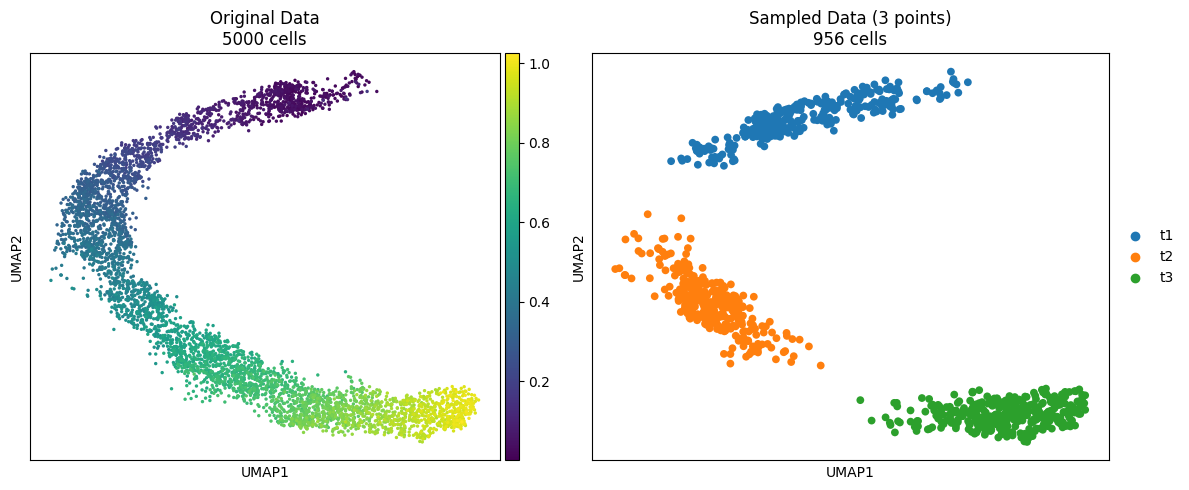


Saved sampled data to: sim_output/simulation_3.h5ad


  0%|          | 0/956 [00:00<?, ?cells/s]

computing velocity graph
finished.


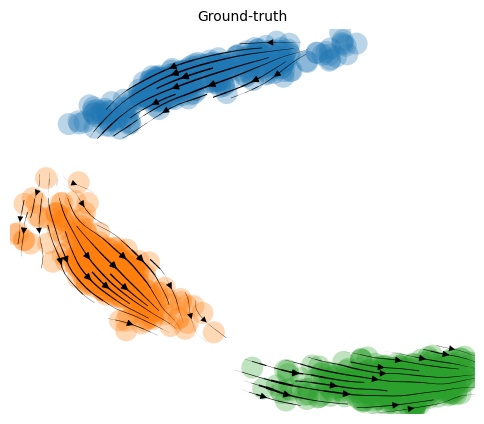

computing velocity embedding
finished.
Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.847880,trend_loss=0.826377,time_loss=0.215029
epoch  51:loss=0.305531,trend_loss=0.303870,time_loss=0.016610
epoch 101:loss=0.246324,trend_loss=0.244863,time_loss=0.014613
epoch 151:loss=0.229586,trend_loss=0.228237,time_loss=0.013493
epoch 201:loss=0.217050,trend_loss=0.215755,time_loss=0.012949
epoch 251:loss=0.197221,trend_loss=0.196052,time_loss=0.011687
Early stopping at epoch 297


  0%|          | 0/956 [00:00<?, ?cells/s]

computing velocity graph
finished.


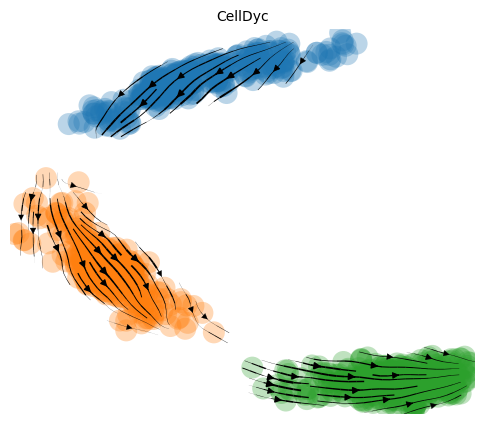

computing velocity embedding
finished.


In [5]:
os.mkdir("./sim_output")
sampling_num = 3
adata_s3 = cdc.rp.sample_along_time(
    adata,
    num=sampling_num,
    time_key="pseudotime",
    save_path=f"sim_output/simulation_{sampling_num}.h5ad",
)
sc.tl.pca(adata_s3, svd_solver="arpack")
sc.pp.neighbors(adata_s3, n_neighbors=30, n_pcs=30)
adata_s3_wot=adata_s3.copy()
adata_s3_moscot=adata_s3.copy()
cdc.pl.plot_velocity_projection(
    adata_s3,
    velocity_key="velocity_true",
    color="sampling_time",
    legend_loc="none",
    title="Ground-truth",
    colorbar=False,
    cmap="tab10",
    figsize=(6,5),
)
cdc.tl.recover_dyc(adata_s3, time_key="sampling_time")
cdc.pl.plot_velocity_projection(
    adata_s3,
    color="sampling_time",
    legend_loc="none",
    title="CellDyc",
    colorbar=False,
    cmap="tab10",
    figsize=(6,5),
)

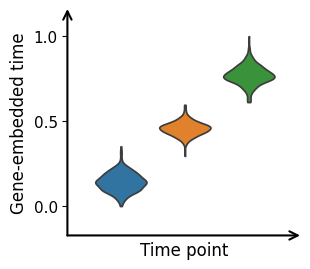

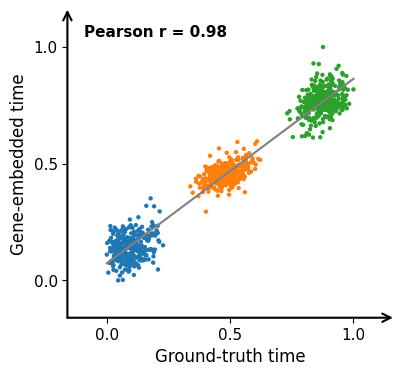

In [11]:
cdc.pl.getime_violin(adata_s3, "getime", "sampling_time")
cdc.pl.getime_correlation(adata_s3, "pseudotime", "getime", "sampling_time_cat",xlabel="Ground-truth time",ylabel="Gene-embedded time",xticks=True)

Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].


  0%|          | 0/2 [00:00<?, ?time pair/s]

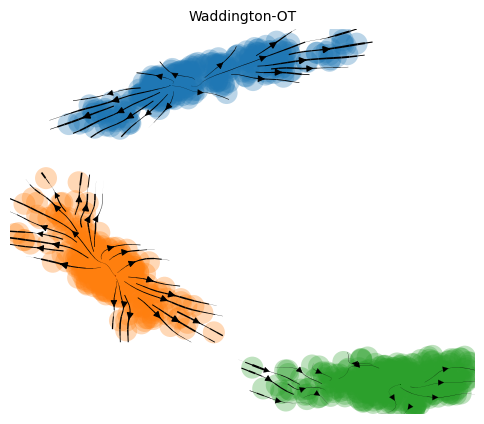

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Solving `2` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(309, 309)].                                    
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(309, 338)].                                    


  0%|          | 0/2 [00:00<?, ?time pair/s]

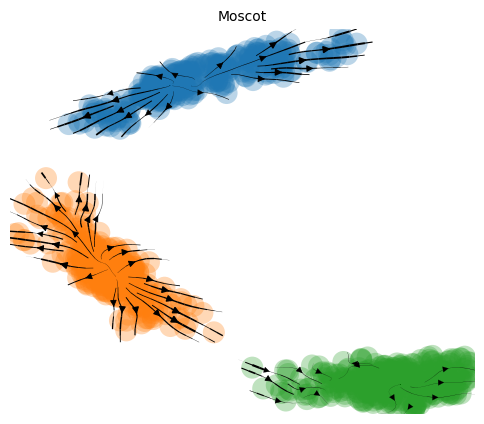

In [12]:
adata_s3_wot.X = adata_s3_wot.X.tocsr()
adata_s3_wot.obs["sampling_time"] = adata_s3_wot.obs["sampling_time"].astype(float).astype("category")
ot_model = wot.ot.OTModel(adata_s3_wot, day_field="sampling_time")
ot_model.compute_all_transport_maps(tmap_out="sim_output/sim3/")
rtk = cr.kernels.RealTimeKernel.from_wot(adata_s3_wot, path="sim_output/sim3/", time_key="sampling_time")
rtk = rtk.compute_transition_matrix()
rtk.plot_projection(basis="umap",connectivities=adata_s3_wot.obsp["connectivities"],color="sampling_time", frameon=False, legend_loc="none",show=False,title="Waddington-OT",figsize=(6,5),cmap="tab10")
ax = plt.gca()
ax.grid(False)
plt.show()

adata_s3_moscot.X = adata_s3_moscot.X.tocsr()
adata_s3_moscot.obs["sampling_time"] = adata_s3_moscot.obs["sampling_time"].astype(float).astype("category")
problem = mt.problems.TemporalProblem(adata_s3_moscot)
problem = problem.prepare(time_key="sampling_time").solve()
rtk = cr.kernels.RealTimeKernel.from_moscot(problem)
rtk = rtk.compute_transition_matrix()
rtk.plot_projection(basis="umap",connectivities=adata_s3_moscot.obsp["connectivities"],color="sampling_time", frameon=False, legend_loc="none",show=False,title="Moscot",figsize=(6,5),cmap="tab10")
ax = plt.gca()
ax.grid(False)
plt.show()

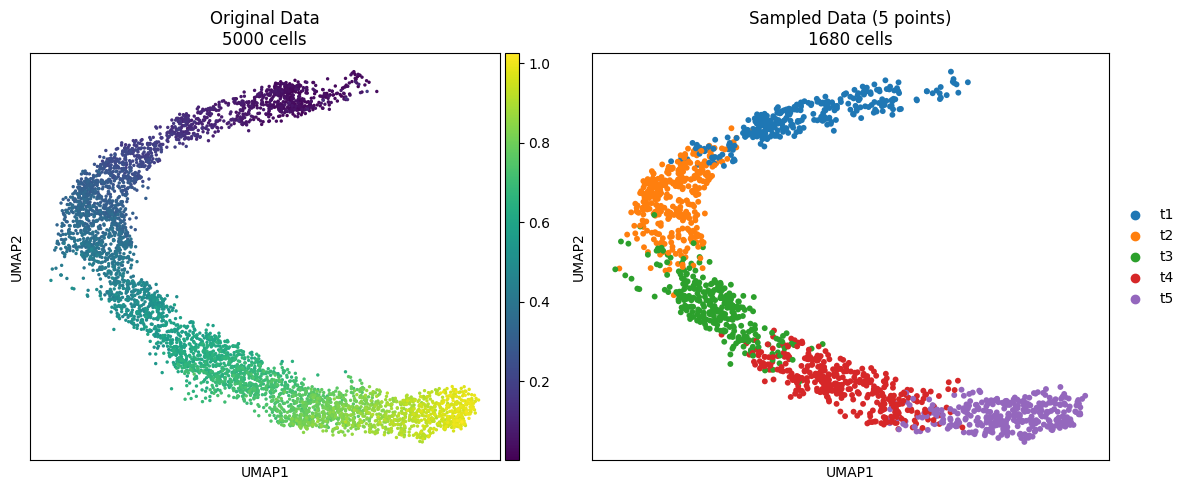


Saved sampled data to: sim_output/simulation_5.h5ad


  0%|          | 0/1680 [00:00<?, ?cells/s]

computing velocity graph
finished.


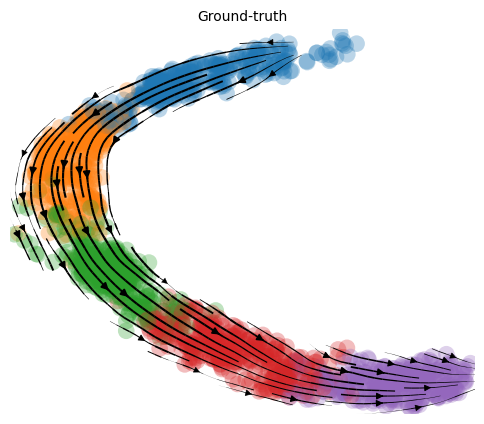

computing velocity embedding
finished.
Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.778464,trend_loss=0.761168,time_loss=0.172957
epoch  51:loss=0.365088,trend_loss=0.362914,time_loss=0.021741
epoch 101:loss=0.343958,trend_loss=0.341800,time_loss=0.021580
epoch 151:loss=0.329381,trend_loss=0.327305,time_loss=0.020765
epoch 201:loss=0.326244,trend_loss=0.324177,time_loss=0.020671
epoch 251:loss=0.315868,trend_loss=0.313845,time_loss=0.020229
epoch 301:loss=0.319462,trend_loss=0.317461,time_loss=0.020014
epoch 351:loss=0.309610,trend_loss=0.307625,time_loss=0.019851
epoch 401:loss=0.312093,trend_loss=0.310107,time_loss=0.019866
Early stopping at epoch 431


  0%|          | 0/1680 [00:00<?, ?cells/s]

computing velocity graph
finished.


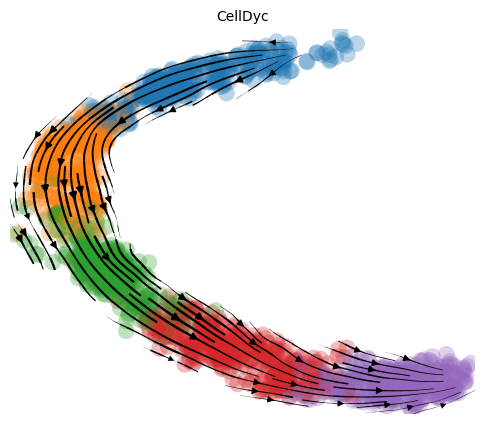

computing velocity embedding
finished.


In [6]:
sampling_num = 5
adata_s5 = cdc.rp.sample_along_time(
    adata,
    num=sampling_num,
    time_key="pseudotime",
    save_path=f"sim_output/simulation_{sampling_num}.h5ad",
)
sc.tl.pca(adata_s5, svd_solver="arpack")
sc.pp.neighbors(adata_s5, n_neighbors=30, n_pcs=30)
adata_s5_wot=adata_s5.copy()
adata_s5_moscot=adata_s5.copy()
cdc.pl.plot_velocity_projection(
    adata_s5,
    velocity_key="velocity_true",
    color="sampling_time",
    legend_loc="none",
    title="Ground-truth",
    colorbar=False,
    cmap="tab10",
    figsize=(6,5),
)
cdc.tl.recover_dyc(adata_s5, time_key="sampling_time")
cdc.pl.plot_velocity_projection(
    adata_s5,
    color="sampling_time",
    legend_loc="none",
    title="CellDyc",
    colorbar=False,
    cmap="tab10",
    figsize=(6,5),
)

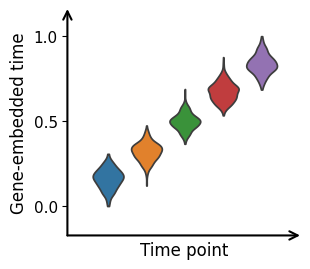

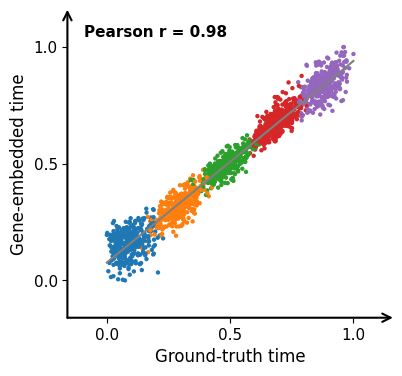

In [14]:
cdc.pl.getime_violin(adata_s5, "getime", "sampling_time")
cdc.pl.getime_correlation(adata_s5, "pseudotime", "getime", "sampling_time_cat",xlabel="Ground-truth time",ylabel="Gene-embedded time",xticks=True)

Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].


  0%|          | 0/4 [00:00<?, ?time pair/s]

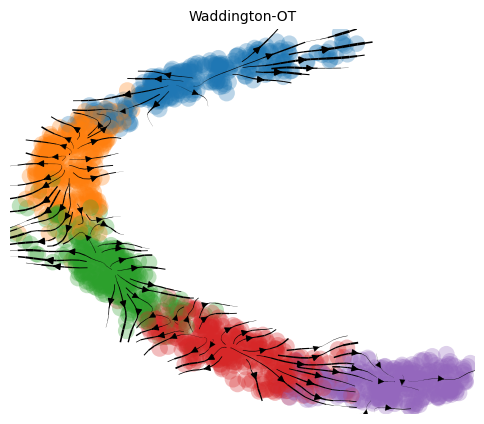

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Solving `4` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(309, 347)].                                    
WARNING  Solver did not converge                                                                                   
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(347, 314)].                                    
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(314,

  0%|          | 0/4 [00:00<?, ?time pair/s]

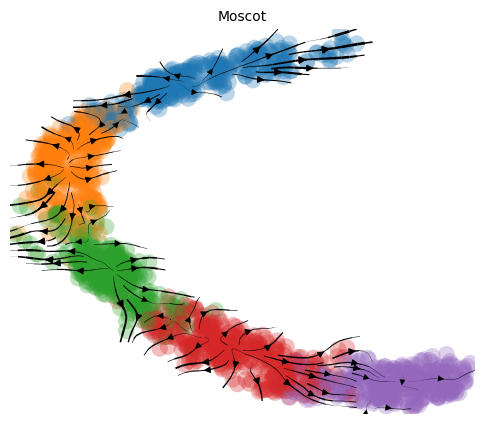

In [7]:
adata_s5_wot.X = adata_s5_wot.X.tocsr()
adata_s5_wot.obs["sampling_time"] = adata_s5_wot.obs["sampling_time"].astype(float).astype("category")
ot_model = wot.ot.OTModel(adata_s5_wot, day_field="sampling_time")
ot_model.compute_all_transport_maps(tmap_out="sim_output/sim5/")
rtk = cr.kernels.RealTimeKernel.from_wot(adata_s5_wot, path="sim_output/sim5/", time_key="sampling_time")
rtk = rtk.compute_transition_matrix()
rtk.plot_projection(basis="umap",connectivities=adata_s5_wot.obsp["connectivities"],color="sampling_time", frameon=False, legend_loc="none",show=False,title="Waddington-OT",figsize=(6,5),cmap="tab10")
ax = plt.gca()
ax.grid(False)
plt.show()

adata_s5_moscot.X = adata_s5_moscot.X.tocsr()
adata_s5_moscot.obs["sampling_time"] = adata_s5_moscot.obs["sampling_time"].astype(float).astype("category")
problem = mt.problems.TemporalProblem(adata_s5_moscot)
problem = problem.prepare(time_key="sampling_time").solve()
rtk = cr.kernels.RealTimeKernel.from_moscot(problem)
rtk = rtk.compute_transition_matrix()
rtk.plot_projection(basis="umap",connectivities=adata_s5_moscot.obsp["connectivities"],color="sampling_time", frameon=False, legend_loc="none",show=False,title="Moscot",figsize=(6,5),cmap="tab10")
ax = plt.gca()
ax.grid(False)
plt.show()

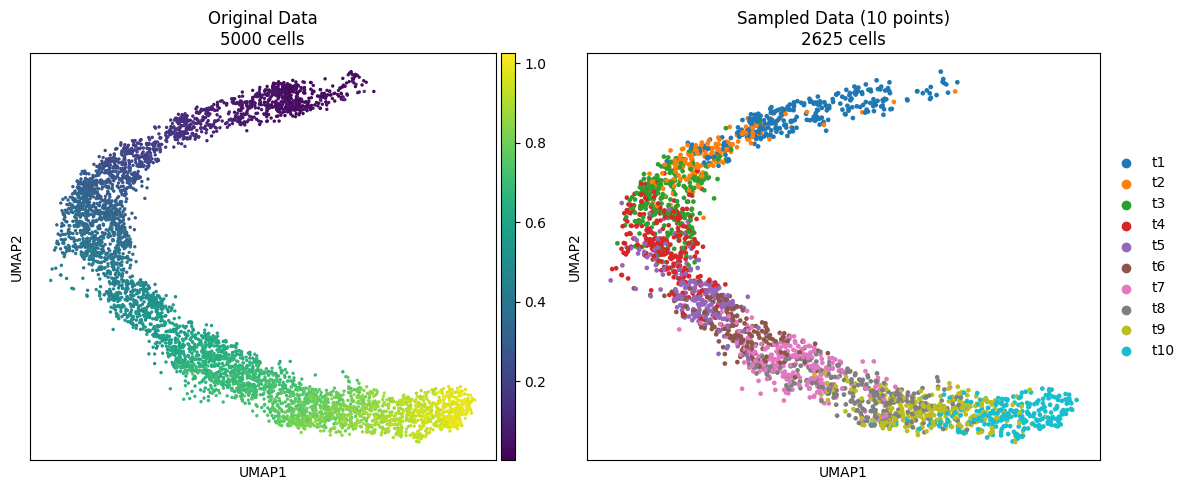


Saved sampled data to: sim_output/simulation_10.h5ad


  0%|          | 0/2625 [00:00<?, ?cells/s]

computing velocity graph
finished.


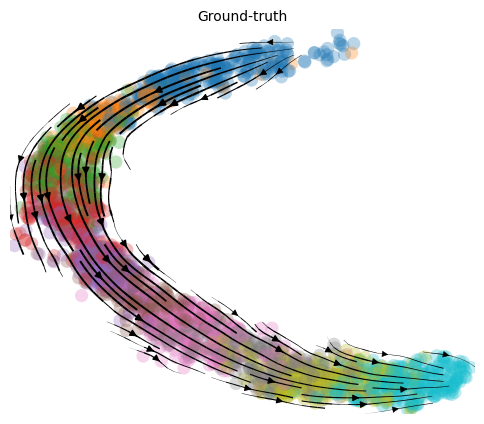

computing velocity embedding
finished.
Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.725435,trend_loss=0.712141,time_loss=0.132941
epoch  51:loss=0.416281,trend_loss=0.413921,time_loss=0.023608
epoch 101:loss=0.400934,trend_loss=0.398600,time_loss=0.023338
epoch 151:loss=0.399729,trend_loss=0.397398,time_loss=0.023315
Early stopping at epoch 198


  0%|          | 0/2625 [00:00<?, ?cells/s]

computing velocity graph
finished.


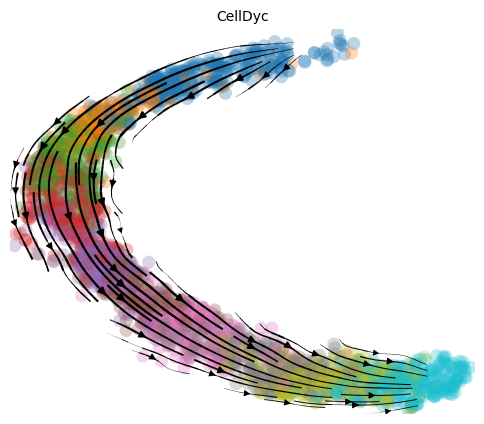

computing velocity embedding
finished.


In [8]:
sampling_num = 10
adata_s10 = cdc.rp.sample_along_time(
    adata,
    num=sampling_num,
    time_key="pseudotime",
    save_path=f"sim_output/simulation_{sampling_num}.h5ad",
)
sc.tl.pca(adata_s10, svd_solver="arpack")
sc.pp.neighbors(adata_s10, n_neighbors=30, n_pcs=30)
adata_s10_wot=adata_s10.copy()
adata_s10_moscot=adata_s10.copy()
cdc.pl.plot_velocity_projection(
    adata_s10,
    velocity_key="velocity_true",
    color="sampling_time",
    legend_loc="none",
    title="Ground-truth",
    colorbar=False,
    cmap="tab10",
    figsize=(6, 5),
)
cdc.tl.recover_dyc(adata_s10, time_key="sampling_time")
cdc.pl.plot_velocity_projection(
    adata_s10,
    color="sampling_time",
    legend_loc="none",
    title="CellDyc",
    colorbar=False,
    cmap="tab10",
    figsize=(6, 5),
)

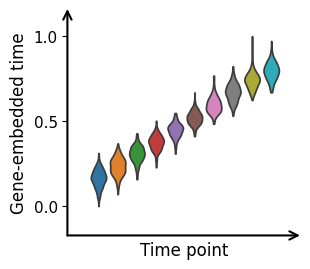

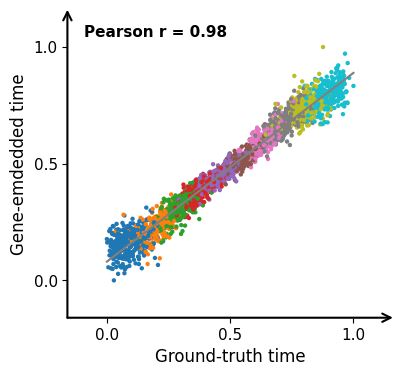

In [17]:
cdc.pl.getime_violin(adata_s10, "getime", "sampling_time")
cdc.pl.getime_correlation(adata_s10, "pseudotime", "getime", "sampling_time_cat",xlabel="Ground-truth time",ylabel="Gene-emdedded time",xticks=True)

Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].
Only considering the two last: ['.0', '.h5ad'].


  0%|          | 0/9 [00:00<?, ?time pair/s]

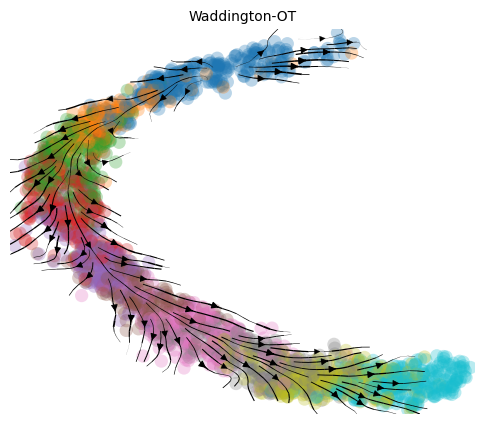

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`       

  0%|          | 0/9 [00:00<?, ?time pair/s]

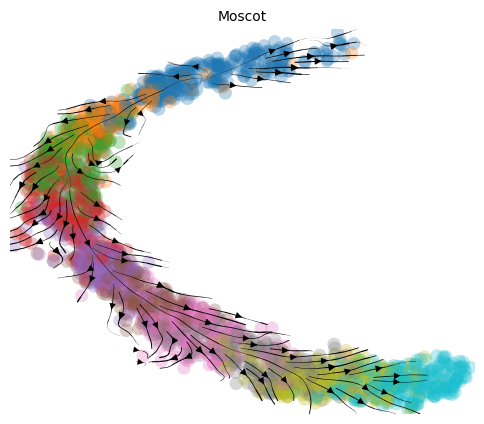

In [18]:
adata_s10_wot.X = adata_s10_wot.X.tocsr()
adata_s10_wot.obs["sampling_time"] = adata_s10_wot.obs["sampling_time"].astype(float).astype("category")
ot_model = wot.ot.OTModel(adata_s10_wot, day_field="sampling_time")
ot_model.compute_all_transport_maps(tmap_out="sim_output/sim10/")
rtk = cr.kernels.RealTimeKernel.from_wot(adata_s10_wot, path="sim_output/sim10/", time_key="sampling_time")
rtk = rtk.compute_transition_matrix()
rtk.plot_projection(basis="umap",connectivities=adata_s10_wot.obsp["connectivities"],color="sampling_time", frameon=False, legend_loc="none",show=False,title="Waddington-OT",figsize=(6,5),cmap="tab10")
ax = plt.gca()
ax.grid(False)
plt.show()

adata_s10_moscot.X = adata_s10_moscot.X.tocsr()
adata_s10_moscot.obs["sampling_time"] = adata_s10_moscot.obs["sampling_time"].astype(float).astype("category")
problem = mt.problems.TemporalProblem(adata_s10_moscot)
problem = problem.prepare(time_key="sampling_time").solve()
rtk = cr.kernels.RealTimeKernel.from_moscot(problem)
rtk = rtk.compute_transition_matrix()
rtk.plot_projection(basis="umap",connectivities=adata_s10_moscot.obsp["connectivities"],color="sampling_time", frameon=False, legend_loc="none",show=False,title="Moscot",figsize=(6,5),cmap="tab10")
ax = plt.gca()
ax.grid(False)
plt.show()